# Convolutional Neural Network - Pytorch 

The following libraries are required to run this module.

In [13]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

The CIFAR-10 dataset is loaded directly from torchvision. It is split into training set (50,000 images) and test set (10,000 images). Both sets contain 32x32 RGB images across 10 mutually exclusive classes.

In [15]:
train_df = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True
)

test_df = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    download=True
)

train_df.data.shape, test_df.data.shape

c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


((50000, 32, 32, 3), (10000, 32, 32, 3))

Based on the dataset, each image in CIFAR-10 has the following dimensions:

In [16]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3

Images are converted from PIL fromat to tensors. The same transform is applied to both the training and test sets.

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_df.transform = transform
test_df.transform = transform

Let's display some sample images from the training set with their class labels. This step was generated by AI because is out of the scope of the main task.

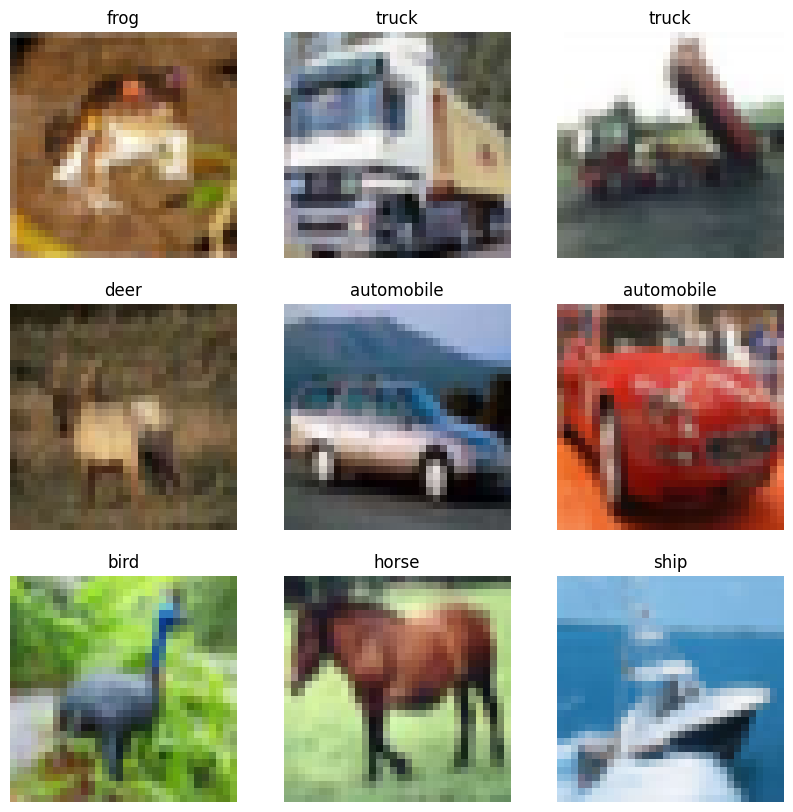

In [18]:
# Generated by AI
class_names = train_df.classes
X_batch, y_batch = train_df.data[:9], train_df.targets[:9]

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_batch[i])
    plt.title(class_names[y_batch[i]])
    plt.axis("off")
plt.show()

We need to create dataloaders for our training and test datasets. Dataloaders will allow us to load our data in batches, which is essential for training our model efficiently. We will use a batch size of 32 for both the training and test dataloaders.

In [19]:
batch_size = 32
train_dataloader = DataLoader(train_df, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_df, batch_size=batch_size, shuffle=False)

Now, let's define the training and testing loops.

In [20]:
def train(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_acc = 0

        for X_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            correct = (outputs.argmax(dim=1) == y_batch).sum().item()
            train_acc += correct / len(y_batch)

        epoch_train_loss = train_loss / len(train_dataloader)
        epoch_train_acc = train_acc / len(train_dataloader)

        model.eval()
        test_acc = 0
        test_loss = 0

        with torch.inference_mode():
            for X_batch, y_batch in test_dataloader:
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                test_loss += loss.item()

                correct = (outputs.argmax(dim=1) == y_batch).sum().item()
                test_acc += correct / len(y_batch)

        epoch_test_loss = test_loss / len(test_dataloader)
        epoch_test_acc = test_acc / len(test_dataloader)

        print(f'Epoch {epoch + 1}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.4f}')

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(epoch_test_acc)

    return res

In [21]:
def evaluate(model, test_dataloader, loss_fn):
    model.eval()
    test_acc = 0
    test_loss = 0

    with torch.inference_mode():
        for X_batch, y_batch in test_dataloader:
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            test_loss += loss.item()

            correct = (outputs.argmax(dim=1) == y_batch).sum().item()
            test_acc += correct / len(y_batch)

    epoch_test_loss = test_loss / len(test_dataloader)
    epoch_test_acc = test_acc / len(test_dataloader)

    return epoch_test_loss, epoch_test_acc

### First Convolutional Neural Network

Now, we have our data in the form of tensors, we can start building a model. Let's create a simple convolutional neural network (CNN) using PyTorch's `nn.Module`.

In [22]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(.3),       
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(64, 64, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 256), 
    nn.Dropout(.5),           
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_cnn = model_cnn.to(device)

Then, we need to define a loss function and an optimizer for training the model. We will use `CrossEntropyLoss` as the loss function and Adam as the optimizer. Also, we will set the number of epochs for training the model. `CrossEntropyLoss` is selected because CIFAR-10 is a multiclass classification problem. 

In [23]:
epochs = 20
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

Now, let's train the first model.

In [24]:
cnn_res = train(model_cnn, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch 1, Train Loss: 1.4838, Train Acc: 0.4560, Test Loss: 1.1968, Test Acc: 0.5987
Epoch 2, Train Loss: 1.1212, Train Acc: 0.6033, Test Loss: 1.0614, Test Acc: 0.6420
Epoch 3, Train Loss: 0.9809, Train Acc: 0.6576, Test Loss: 0.8907, Test Acc: 0.6973
Epoch 4, Train Loss: 0.8874, Train Acc: 0.6896, Test Loss: 0.8428, Test Acc: 0.7121
Epoch 5, Train Loss: 0.8263, Train Acc: 0.7121, Test Loss: 0.8166, Test Acc: 0.7214
Epoch 6, Train Loss: 0.7815, Train Acc: 0.7273, Test Loss: 0.7914, Test Acc: 0.7254
Epoch 7, Train Loss: 0.7428, Train Acc: 0.7387, Test Loss: 0.7440, Test Acc: 0.7428
Epoch 8, Train Loss: 0.7041, Train Acc: 0.7533, Test Loss: 0.7362, Test Acc: 0.7500
Epoch 9, Train Loss: 0.6869, Train Acc: 0.7598, Test Loss: 0.7399, Test Acc: 0.7493
Epoch 10, Train Loss: 0.6580, Train Acc: 0.7683, Test Loss: 0.7613, Test Acc: 0.7405
Epoch 11, Train Loss: 0.6397, Train Acc: 0.7751, Test Loss: 0.7358, Test Acc: 0.7463
Epoch 12, Train Loss: 0.6161, Train Acc: 0.7830, Test Loss: 0.6975, Test A

The following graph shows the learning curves for train and test loss accros epochs.

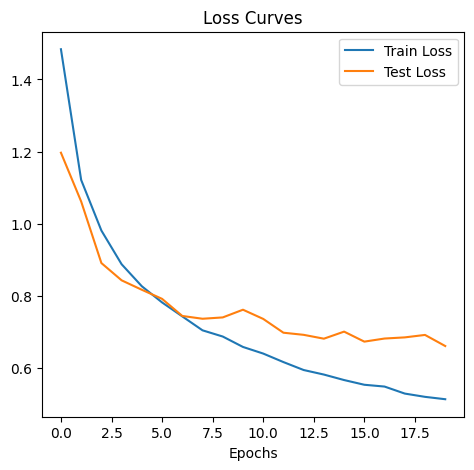

In [25]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

### Second Convolutional Neural Network

In [26]:
model_cnn_2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1), # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), # 25 x 16 x 16

    nn.Conv2d(25, 50, 3, stride=1, padding=1), # 50 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2), # 50 x 8 x 8

    nn.Conv2d(50, 75, 3, stride=1, padding=1), # 75 x 8 x 8
    nn.ReLU(),  
    nn.MaxPool2d(2, stride=2), # 75 x 4 x 4
    
    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model_cnn_2 = model_cnn_2.to(device)

In [27]:
epochs = 20
optimizer = torch.optim.Adam(model_cnn_2.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

In [28]:
cnn_res_2 = train(model_cnn_2, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch 1, Train Loss: 1.3757, Train Acc: 0.5000, Test Loss: 1.1272, Test Acc: 0.6040
Epoch 2, Train Loss: 0.9770, Train Acc: 0.6555, Test Loss: 0.8717, Test Acc: 0.6988
Epoch 3, Train Loss: 0.8159, Train Acc: 0.7154, Test Loss: 0.8168, Test Acc: 0.7157
Epoch 4, Train Loss: 0.7177, Train Acc: 0.7480, Test Loss: 0.7397, Test Acc: 0.7409
Epoch 5, Train Loss: 0.6431, Train Acc: 0.7748, Test Loss: 0.7274, Test Acc: 0.7451
Epoch 6, Train Loss: 0.5881, Train Acc: 0.7923, Test Loss: 0.7007, Test Acc: 0.7590
Epoch 7, Train Loss: 0.5385, Train Acc: 0.8104, Test Loss: 0.6834, Test Acc: 0.7648
Epoch 8, Train Loss: 0.4923, Train Acc: 0.8242, Test Loss: 0.6966, Test Acc: 0.7631
Epoch 9, Train Loss: 0.4595, Train Acc: 0.8369, Test Loss: 0.6975, Test Acc: 0.7667
Epoch 10, Train Loss: 0.4255, Train Acc: 0.8481, Test Loss: 0.6685, Test Acc: 0.7758
Epoch 11, Train Loss: 0.3985, Train Acc: 0.8574, Test Loss: 0.7238, Test Acc: 0.7534
Epoch 12, Train Loss: 0.3754, Train Acc: 0.8658, Test Loss: 0.7153, Test A

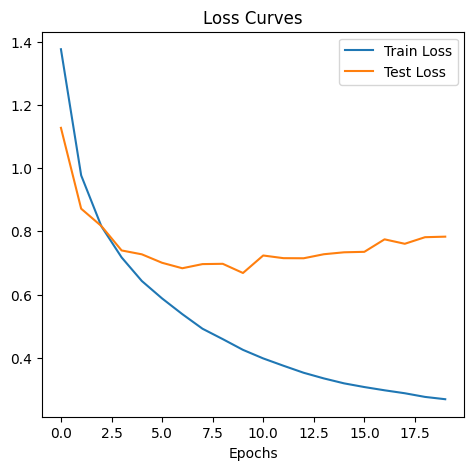

In [29]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res_2['train_loss'], label='Train Loss')
plt.plot(cnn_res_2['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

### Third Convolutional Neural Network

In [30]:
model_cnn_3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(32, 64, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.Dropout(.5),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(64, 128, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.Dropout(.5),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model_cnn_3 = model_cnn_3.to(device)

In [31]:
epochs = 20
optimizer = torch.optim.Adam(model_cnn_3.parameters(), lr=0.0001, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

In [32]:
cnn_res_3 = train(model_cnn_3, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch 1, Train Loss: 1.6853, Train Acc: 0.3866, Test Loss: 1.5441, Test Acc: 0.4920
Epoch 2, Train Loss: 1.3784, Train Acc: 0.5027, Test Loss: 1.4003, Test Acc: 0.5423
Epoch 3, Train Loss: 1.2594, Train Acc: 0.5486, Test Loss: 1.3064, Test Acc: 0.5860
Epoch 4, Train Loss: 1.1701, Train Acc: 0.5844, Test Loss: 1.2272, Test Acc: 0.6174
Epoch 5, Train Loss: 1.0914, Train Acc: 0.6145, Test Loss: 1.1864, Test Acc: 0.6371
Epoch 6, Train Loss: 1.0276, Train Acc: 0.6364, Test Loss: 1.1130, Test Acc: 0.6497
Epoch 7, Train Loss: 0.9763, Train Acc: 0.6560, Test Loss: 1.0549, Test Acc: 0.6689
Epoch 8, Train Loss: 0.9290, Train Acc: 0.6724, Test Loss: 1.0839, Test Acc: 0.6548
Epoch 9, Train Loss: 0.8819, Train Acc: 0.6906, Test Loss: 1.0053, Test Acc: 0.6954
Epoch 10, Train Loss: 0.8483, Train Acc: 0.7033, Test Loss: 0.9836, Test Acc: 0.6881
Epoch 11, Train Loss: 0.8092, Train Acc: 0.7165, Test Loss: 0.9407, Test Acc: 0.7056
Epoch 12, Train Loss: 0.7705, Train Acc: 0.7323, Test Loss: 0.9168, Test A

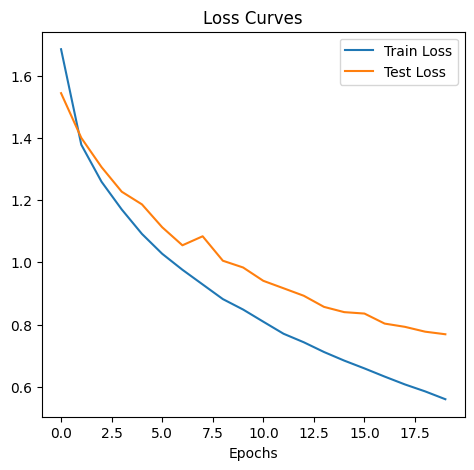

In [33]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res_3['train_loss'], label='Train Loss')
plt.plot(cnn_res_3['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

Now, evaluate the models on the test set and compare their performance.


In [35]:
models = [model_cnn, model_cnn_2, model_cnn_3]
results = []
for model in models:
    test_loss, test_acc = evaluate(model, test_dataloader, loss_fn)
    results.append((test_loss, test_acc))

for i, (loss, acc) in enumerate(results):
    print(f"Model {i+1}: Test Loss = {loss:.4f}, Test Accuracy = {acc:.4f}")

Model 1: Test Loss = 0.6606, Test Accuracy = 0.7751
Model 2: Test Loss = 0.7833, Test Accuracy = 0.7752
Model 3: Test Loss = 0.7689, Test Accuracy = 0.7553


## Final Remarks

In this notebook, I had the opportunity to experiment with Convolutional Neural Networks. It was interesting because first I had to select the proper hyperparameters and then just focus on the model architecture. But the interesting part of it was that the first model was the best model based on the test accuracy. The first model had overfitting, and I tried to add some methods to reduce it, but they did not work very well. However, it showed the best results out of these three models, even though I did not use a lot of layers in the architecture. 

For the second model, I just changed the Dropout in the CNN, as a result, we did not see much difference between the first and second models. Then, in the third model, I tried to add more layers, but the results were not great. The accuracy dropped, so the model was not learning well, and we could also see overfitting. This means that even if we generate a complex architecture for a CNN, it does not guarantee that the model is going to have a great performance, so you have to understand the data you are working with.

Finally, this exercise was great, it allowed me to play with some CNNs and see how you can structure them to achieve better results.